# Notebook 06 - Image Preprocessing Feature Dataset

Notebook ini menyiapkan data gambar untuk baseline image-only dan model multimodal.

Tahap ini **belum melakukan training model**. Output notebook ini akan dipakai oleh:

- Notebook 08: `image_only_baseline_vit_or_clip`
- Notebook 09: `late_fusion_multimodal_baseline`
- Notebook 10: `cross_modal_or_gated_fusion_model`
- Notebook 11: `noise_aware_relation_ablation`

Fokus Notebook 06:

1. Membaca `final_image_manifest_all_valid.csv` dari Notebook 03.
2. Menyesuaikan path gambar dengan folder `image_cache` di Kaggle input.
3. Validasi semua file gambar: exists, corrupt image, ukuran, mode warna, format, dan aspect ratio.
4. Menyimpan manifest final image-level dan review-level multi-image mapping.
5. Menyiapkan kebijakan preprocessing untuk CLIP/ViT: RGB conversion, resize/crop berbasis image processor, dan label matrix 7 aspek.
6. Membuat sample tensor batch kecil sebagai smoke test, tanpa menyimpan ulang seluruh gambar sebagai tensor besar.

## Dasar Metodologis

Tahap ini memakai preprocessing visual yang konsisten dengan model pretrained.

1. **Vision Transformer (ViT)** memecah gambar menjadi patch visual berukuran tetap. Karena itu, input image perlu ukuran konsisten, biasanya `224x224`, agar sesuai dengan konfigurasi patch dan positional embedding model pretrained.

2. **CLIP** mempelajari representasi visual dari pasangan image-text skala besar. Karena penelitian ini akan membandingkan image-only dan multimodal, CLIP/ViT menjadi encoder visual yang metodologis untuk baseline dan fusion.

3. **Model-specific image processor lebih aman daripada transform manual sembarang.** Encoder pretrained memiliki asumsi preprocessing seperti resize, crop, mean, dan standard deviation. Notebook ini memakai `AutoImageProcessor` bila tersedia, lalu fallback ke resize RGB manual hanya untuk sanity check.

4. **Dataset kamu multi-image per review.** Karena satu review bisa memiliki banyak gambar, representasi final harus mempertahankan image-level row dan review-level grouping. Ini mencegah kebocoran split dan memudahkan eksperimen agregasi multi-image di Notebook 08 sampai 10.

Referensi:

- Dosovitskiy et al. (2021), *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. https://arxiv.org/abs/2010.11929
- Radford et al. (2021), *Learning Transferable Visual Models From Natural Language Supervision*. https://proceedings.mlr.press/v139/radford21a.html
- He et al. (2016), *Deep Residual Learning for Image Recognition*. https://arxiv.org/abs/1512.03385
- Buda, Maki, & Mazurowski (2018), *A systematic study of the class imbalance problem in convolutional neural networks*. https://doi.org/10.1016/j.neunet.2018.07.011

### 1. Import Library dan Persiapan Direktori Output


In [1]:
from pathlib import Path
import json
import math
import os
import re
import shutil
import subprocess
import sys
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, UnidentifiedImageError

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

SEED = 42
IMAGE_MODEL_NAME = os.environ.get("IMAGE_MODEL_NAME", "openai/clip-vit-base-patch32")
TARGET_IMAGE_SIZE = int(os.environ.get("TARGET_IMAGE_SIZE", "224"))
SAMPLE_BATCH_SIZE = int(os.environ.get("IMAGE_SAMPLE_BATCH_SIZE", "16"))

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
LABEL_TO_ID = {"None": 0, "Negatif": 1, "Netral": 2, "Positif": 3}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
SPLIT_ORDER = ["train", "val", "test"]

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_image_preprocessing_feature_outputs") if IS_KAGGLE else Path("mabsa_image_preprocessing_feature_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)
print("Image model name:", IMAGE_MODEL_NAME)
print("Target image size:", TARGET_IMAGE_SIZE)

Output directory: /kaggle/working/mabsa_image_preprocessing_feature_outputs
Kaggle environment: True
Image model name: openai/clip-vit-base-patch32
Target image size: 224


### 2. Fungsi Pencarian Path File Dataset dan Metadata


In [2]:
def find_file(filename):
    candidates = []

    if IS_KAGGLE:
        candidates.append(Path("/kaggle/working/mabsa_final_dataset_outputs") / filename)
        input_root = Path("/kaggle/input")
        if input_root.exists():
            candidates.extend(input_root.rglob(filename))

    local_candidates = [
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data\mabsa_final_dataset_outputs") / filename,
        Path(r"G:\Skripsi\Data Preprocessing\mabsa_final_dataset_outputs") / filename,
    ]
    candidates.extend(local_candidates)

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Tidak menemukan {filename}. Jalankan Notebook 03 lebih dulu atau upload output Notebook 03 sebagai Kaggle input."
    )


DATASET_FILES = {
    "all_valid": "final_image_manifest_all_valid.csv",
    "primary_training": "final_image_manifest_primary_training.csv",
    "relation_aware": "final_image_manifest_relation_aware.csv",
    "contradiction_ablation": "final_image_manifest_contradiction_ablation.csv",
}

paths = {name: find_file(filename) for name, filename in DATASET_FILES.items()}
paths["review_all_valid"] = find_file("final_review_dataset_all_valid.csv")
paths["label_mapping"] = find_file("label_mapping.json")

for name, path in paths.items():
    print(f"{name:24s}: {path}")

all_valid               : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_image_manifest_all_valid.csv
primary_training        : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_image_manifest_primary_training.csv
relation_aware          : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_image_manifest_relation_aware.csv
contradiction_ablation  : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_image_manifest_contradiction_ablation.csv
review_all_valid        : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_all_valid.csv
label_mapping           : /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/label_mapping.json


### 3. Memuat Dataset Gambar dan Image Manifest (Output Notebook 03)


In [3]:
image_datasets = {name: pd.read_csv(path) for name, path in paths.items() if name in DATASET_FILES}
review_all_valid = pd.read_csv(paths["review_all_valid"])

with open(paths["label_mapping"], "r", encoding="utf-8") as f:
    label_mapping_from_notebook_03 = json.load(f)

image_manifest = image_datasets["all_valid"].copy()

print("Image dataset shapes:")
for name, df in image_datasets.items():
    print(f"- {name:22s}: {df.shape}")
print("review_all_valid:", review_all_valid.shape)
print("label mapping:", label_mapping_from_notebook_03)

display(image_manifest.head(5))

Image dataset shapes:
- all_valid             : (17371, 35)
- primary_training      : (13976, 35)
- relation_aware        : (13958, 35)
- contradiction_ablation: (3395, 35)
review_all_valid: (8030, 66)
label mapping: {'label_to_id': {'None': 0, 'Negatif': 1, 'Netral': 2, 'Positif': 3}, 'id_to_label': {'0': 'None', '1': 'Negatif', '2': 'Netral', '3': 'Positif'}, 'aspect_to_id': {'Kamar': 0, 'Kebersihan': 1, 'Pelayanan': 2, 'Harga': 3, 'Lokasi': 4, 'Fasilitas': 5, 'Makanan': 6}}


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,Gambar_Ke,Image_FileName,Image_Path,image_path_found,dataset_role,split,relation_category,relation_strength,policy_bucket,recommended_fusion_strategy,is_excluded_final,primary_training_candidate,core_clean_candidate,relation_aware_candidate,contradiction_ablation_candidate,label_image_Kamar,label_image_id_Kamar,label_image_Kebersihan,label_image_id_Kebersihan,label_image_Pelayanan,label_image_id_Pelayanan,label_image_Harga,label_image_id_Harga,label_image_Lokasi,label_image_id_Lokasi,label_image_Fasilitas,label_image_id_Fasilitas,label_image_Makanan,label_image_id_Makanan
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat istirahat, lokasi strat...",1,R1_G1_687bd728.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R1_G1_687bd728.jpg,True,contradiction_ablation,train,correlated_but_contradictive,conflict,contradiction_ablation,contradiction_aware_or_gated_fusion,False,False,False,False,True,NaN,0,Positif,3,NaN,0,NaN,0,NaN,0,Positif,3,NaN,0
1,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",1,R2_G1_eb4fea87.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G1_eb4fea87.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,NaN,0,NaN,0,NaN,0,NaN,0,Positif,3,NaN,0,NaN,0
2,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",2,R2_G2_3b6a9a2a.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G2_3b6a9a2a.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Netral,2,Netral,2,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
3,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",3,R2_G3_ecd0ece1.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G3_ecd0ece1.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Positif,3,Positif,3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
4,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",4,R2_G4_291b1579.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G4_291b1579.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Positif,3,Positif,3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


## Resolve Path Folder `image_cache`

Notebook 03 menyimpan `Image_Path`. Namun path Kaggle dapat berubah jika dataset input berbeda.

Karena itu Notebook 06:

1. mengecek apakah `Image_Path` masih valid;
2. jika kosong/tidak valid, melakukan scan `/kaggle/input`;
3. mencocokkan file berdasarkan `Image_FileName`;
4. memprioritaskan folder yang mengandung nama `image_cache` bila ditemukan.

### 4. Fungsi Normalisasi Kolom Label dan Cleaning Data


In [4]:
def normalize_label(value):
    if pd.isna(value):
        return "None"
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "null"}:
        return "None"
    return text


def clean_bool(value):
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"true", "1", "yes"}


def path_exists(value):
    if pd.isna(value):
        return False
    text = str(value).strip()
    if not text:
        return False
    return Path(text).exists()


def scan_image_cache(target_filenames):
    target_filenames = set(str(name) for name in target_filenames if pd.notna(name) and str(name).strip())
    image_index = {}
    duplicate_hits = defaultdict(list)
    if not target_filenames:
        return image_index, duplicate_hits

    roots = []
    if IS_KAGGLE and Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))

    local_roots = [
        Path(r"G:\Skripsi"),
        Path(r"C:\Users\cencen04_\Downloads"),
    ]
    roots.extend([root for root in local_roots if root.exists()])

    image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

    for root in roots:
        try:
            for path in root.rglob("*"):
                if not path.is_file() or path.suffix.lower() not in image_extensions:
                    continue
                if path.name not in target_filenames:
                    continue

                duplicate_hits[path.name].append(str(path))
                current = image_index.get(path.name)
                if current is None:
                    image_index[path.name] = str(path)
                else:
                    # Prefer image_cache paths when duplicate filenames exist.
                    current_score = 1 if "image_cache" in current.lower() else 0
                    new_score = 1 if "image_cache" in str(path).lower() else 0
                    if new_score > current_score:
                        image_index[path.name] = str(path)
        except Exception as exc:
            print(f"Skip scan root {root}: {exc}")

    return image_index, duplicate_hits


if "Image_Path" not in image_manifest.columns:
    image_manifest["Image_Path"] = ""

image_manifest["existing_path_valid_before_resolve"] = image_manifest["Image_Path"].map(path_exists)
missing_or_invalid = ~image_manifest["existing_path_valid_before_resolve"]
print("Rows with missing/invalid Image_Path before resolve:", int(missing_or_invalid.sum()))

if missing_or_invalid.any():
    target_filenames = image_manifest.loc[missing_or_invalid, "Image_FileName"].dropna().astype(str).unique()
    print("Scanning image_cache candidates for filenames:", len(target_filenames))
    start_time = time.time()
    image_path_index, duplicate_hits = scan_image_cache(target_filenames)
    print("Resolved paths:", len(image_path_index))
    print("Scan seconds:", round(time.time() - start_time, 2))

    resolved_paths = image_manifest.loc[missing_or_invalid, "Image_FileName"].map(image_path_index)
    resolved_index = resolved_paths.dropna().index
    image_manifest.loc[resolved_index, "Image_Path"] = resolved_paths.loc[resolved_index]
else:
    duplicate_hits = defaultdict(list)

image_manifest["image_path_found"] = image_manifest["Image_Path"].map(path_exists)
image_manifest["Image_Path"] = image_manifest["Image_Path"].fillna("").astype(str)

duplicate_filename_scan = pd.DataFrame([
    {"Image_FileName": filename, "hit_count": len(paths), "paths": "|".join(paths)}
    for filename, paths in duplicate_hits.items()
    if len(paths) > 1
])

print("Image path found:", int(image_manifest["image_path_found"].sum()), "/", len(image_manifest))
print("Missing image paths:", int((~image_manifest["image_path_found"]).sum()))
display(duplicate_filename_scan.head(20))

Rows with missing/invalid Image_Path before resolve: 0
Image path found: 17371 / 17371
Missing image paths: 0


""


## Validasi Gambar

Validasi dilakukan dengan PIL:

- file exists;
- dapat dibuka;
- `verify()` tidak gagal;
- dapat di-load ulang dan dikonversi ke RGB;
- ukuran width/height valid;
- flag untuk gambar terlalu kecil atau aspect ratio ekstrem.

Notebook ini tidak menghapus gambar secara fisik. Jika ada invalid image, barisnya diberi flag agar bisa dieksklusi pada training.

### 5. Definisi Fungsi Validasi Fisik File Gambar (Eksistensi, Mode, File Rusak)


In [5]:
def validate_image_file(row):
    image_path = row.get("Image_Path", "")
    result = {
        "ID_Review": row.get("ID_Review"),
        "Image_FileName": row.get("Image_FileName"),
        "Image_Path": image_path,
        "file_exists": False,
        "open_ok": False,
        "verify_ok": False,
        "load_ok": False,
        "valid_image": False,
        "format": None,
        "mode": None,
        "width": np.nan,
        "height": np.nan,
        "n_frames": 1,
        "file_size_bytes": np.nan,
        "aspect_ratio": np.nan,
        "min_side": np.nan,
        "max_side": np.nan,
        "is_tiny_image": False,
        "is_extreme_aspect_ratio": False,
        "error": "",
    }

    try:
        path = Path(str(image_path))
        result["file_exists"] = path.exists()
        if not result["file_exists"]:
            result["error"] = "file_not_found"
            return result

        result["file_size_bytes"] = int(path.stat().st_size)

        with Image.open(path) as img:
            result["open_ok"] = True
            result["format"] = img.format
            result["mode"] = img.mode
            result["width"], result["height"] = img.size
            result["n_frames"] = int(getattr(img, "n_frames", 1))
            img.verify()
            result["verify_ok"] = True

        # Re-open after verify because PIL verify invalidates image core.
        with Image.open(path) as img:
            ImageOps.exif_transpose(img).convert("RGB").load()
            result["load_ok"] = True

        width = int(result["width"])
        height = int(result["height"])
        if width > 0 and height > 0:
            aspect_ratio = width / height
            result["aspect_ratio"] = round(float(aspect_ratio), 6)
            result["min_side"] = min(width, height)
            result["max_side"] = max(width, height)
            result["is_tiny_image"] = bool(min(width, height) < 64)
            result["is_extreme_aspect_ratio"] = bool(aspect_ratio > 4.0 or aspect_ratio < 0.25)

        result["valid_image"] = bool(
            result["file_exists"]
            and result["open_ok"]
            and result["verify_ok"]
            and result["load_ok"]
            and int(result["width"]) > 0
            and int(result["height"]) > 0
        )
    except Exception as exc:
        result["error"] = f"{type(exc).__name__}: {exc}"

    return result


audit_rows = []
total_images = len(image_manifest)
start_time = time.time()

for idx, row in image_manifest.iterrows():
    audit_rows.append(validate_image_file(row))
    if (idx + 1) % 1000 == 0:
        print(f"Validated {idx + 1}/{total_images} images...")

image_file_audit = pd.DataFrame(audit_rows)
print("Validation seconds:", round(time.time() - start_time, 2))
print("Valid images:", int(image_file_audit["valid_image"].sum()), "/", len(image_file_audit))
print("Invalid images:", int((~image_file_audit["valid_image"]).sum()))

display(image_file_audit.head(10))
display(image_file_audit.loc[~image_file_audit["valid_image"]].head(20))

Validated 1000/17371 images...
Validated 2000/17371 images...
Validated 3000/17371 images...
Validated 4000/17371 images...
Validated 5000/17371 images...
Validated 6000/17371 images...
Validated 7000/17371 images...
Validated 8000/17371 images...
Validated 9000/17371 images...
Validated 10000/17371 images...
Validated 11000/17371 images...
Validated 12000/17371 images...
Validated 13000/17371 images...
Validated 14000/17371 images...
Validated 15000/17371 images...
Validated 16000/17371 images...
Validated 17000/17371 images...
Validation seconds: 188.94
Valid images: 17371 / 17371
Invalid images: 0


,ID_Review,Image_FileName,Image_Path,file_exists,open_ok,verify_ok,load_ok,valid_image,format,mode,width,height,n_frames,file_size_bytes,aspect_ratio,min_side,max_side,is_tiny_image,is_extreme_aspect_ratio,error
0,1,R1_G1_687bd728.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R1_G1_687bd728.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,111689,0.750000,720,960,False,False,
1,2,R2_G1_eb4fea87.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G1_eb4fea87.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,148936,0.750000,720,960,False,False,
2,2,R2_G2_3b6a9a2a.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G2_3b6a9a2a.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,84924,0.750000,720,960,False,False,
3,2,R2_G3_ecd0ece1.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G3_ecd0ece1.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,83096,0.750000,720,960,False,False,
4,2,R2_G4_291b1579.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G4_291b1579.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,63800,0.750000,720,960,False,False,
5,2,R2_G5_17136c82.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G5_17136c82.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,93539,0.750000,720,960,False,False,
6,3,R3_G1_f3146238.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R3_G1_f3146238.jpg,True,True,True,True,True,JPEG,RGB,720,960,1,91775,0.750000,720,960,False,False,
7,4,R4_G1_3c26b946.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R4_G1_3c26b946.jpg,True,True,True,True,True,JPEG,RGB,720,958,1,117702,0.751566,720,958,False,False,
8,4,R4_G2_b2760d8c.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R4_G2_b2760d8c.jpg,True,True,True,True,True,JPEG,RGB,720,958,1,88724,0.751566,720,958,False,False,
9,4,R4_G3_d956a465.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R4_G3_d956a465.jpg,True,True,True,True,True,JPEG,RGB,720,958,1,110452,0.751566,720,958,False,False,


,ID_Review,Image_FileName,Image_Path,file_exists,open_ok,verify_ok,load_ok,valid_image,format,mode,width,height,n_frames,file_size_bytes,aspect_ratio,min_side,max_side,is_tiny_image,is_extreme_aspect_ratio,error


### 6. Integrasi Hasil Audit Fisik ke Dataset Image Manifest


In [6]:
image_manifest_prepared = image_manifest.merge(
    image_file_audit.drop(columns=["Image_Path"]),
    on=["ID_Review", "Image_FileName"],
    how="left",
)

for aspect in ASPECTS:
    label_col = f"label_image_{aspect}"
    id_col = f"label_image_id_{aspect}"
    if label_col not in image_manifest_prepared.columns:
        if aspect in image_manifest_prepared.columns:
            image_manifest_prepared[label_col] = image_manifest_prepared[aspect].map(normalize_label)
        else:
            image_manifest_prepared[label_col] = "None"
    else:
        image_manifest_prepared[label_col] = image_manifest_prepared[label_col].map(normalize_label)

    image_manifest_prepared[id_col] = image_manifest_prepared[label_col].map(LABEL_TO_ID).fillna(-1).astype(int)

image_manifest_prepared["is_usable_image"] = (
    image_manifest_prepared["image_path_found"].map(clean_bool)
    & image_manifest_prepared["valid_image"].map(clean_bool)
)

image_manifest_prepared["width"] = image_manifest_prepared["width"].astype("Int64")
image_manifest_prepared["height"] = image_manifest_prepared["height"].astype("Int64")

usable_count = int(image_manifest_prepared["is_usable_image"].sum())
print("Usable images:", usable_count, "/", len(image_manifest_prepared))
display(image_manifest_prepared.head(10))

Usable images: 17371 / 17371


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,Gambar_Ke,Image_FileName,Image_Path,image_path_found,dataset_role,split,relation_category,relation_strength,policy_bucket,recommended_fusion_strategy,is_excluded_final,primary_training_candidate,core_clean_candidate,relation_aware_candidate,contradiction_ablation_candidate,label_image_Kamar,label_image_id_Kamar,label_image_Kebersihan,label_image_id_Kebersihan,label_image_Pelayanan,label_image_id_Pelayanan,label_image_Harga,label_image_id_Harga,label_image_Lokasi,label_image_id_Lokasi,label_image_Fasilitas,label_image_id_Fasilitas,label_image_Makanan,label_image_id_Makanan,existing_path_valid_before_resolve,file_exists,open_ok,verify_ok,load_ok,valid_image,format,mode,width,height,n_frames,file_size_bytes,aspect_ratio,min_side,max_side,is_tiny_image,is_extreme_aspect_ratio,error,is_usable_image
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat istirahat, lokasi strat...",1,R1_G1_687bd728.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R1_G1_687bd728.jpg,True,contradiction_ablation,train,correlated_but_contradictive,conflict,contradiction_ablation,contradiction_aware_or_gated_fusion,False,False,False,False,True,None,0,Positif,3,None,0,None,0,None,0,Positif,3,None,0,True,True,True,True,True,True,JPEG,RGB,720,960,1,111689,0.750000,720,960,False,False,,True
1,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",1,R2_G1_eb4fea87.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G1_eb4fea87.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,None,0,None,0,None,0,None,0,Positif,3,None,0,None,0,True,True,True,True,True,True,JPEG,RGB,720,960,1,148936,0.750000,720,960,False,False,,True
2,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",2,R2_G2_3b6a9a2a.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G2_3b6a9a2a.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Netral,2,Netral,2,None,0,None,0,None,0,None,0,None,0,True,True,True,True,True,True,JPEG,RGB,720,960,1,84924,0.750000,720,960,False,False,,True
3,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",3,R2_G3_ecd0ece1.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G3_ecd0ece1.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Positif,3,Positif,3,None,0,None,0,None,0,None,0,None,0,True,True,True,True,True,True,JPEG,RGB,720,960,1,83096,0.750000,720,960,False,False,,True
4,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",4,R2_G4_291b1579.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G4_291b1579.jpg,True,core_clean_training,val,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,False,True,True,True,False,Positif,3,Positif,3,None,0,None,0,None,0,None,0,None,0,True,True,True,True,True,True,JPEG,RGB,720,960,1,63800,0.750000,720,960,False,False,,True
5,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2

## Distribusi Ukuran dan Kualitas Gambar

Bagian ini membantu memutuskan apakah resize ke `224x224` aman.

Jika banyak gambar terlalu kecil atau aspect ratio ekstrem, hasil image encoder bisa kurang stabil. Data kamu tetap dipertahankan, tetapi diberi flag untuk error analysis.

### 7. Kalkulasi Ringkasan Kualitas Gambar Keseluruhan (Quality Summary)


In [7]:
image_quality_summary = pd.DataFrame([
    {
        "total_rows": int(len(image_manifest_prepared)),
        "path_found": int(image_manifest_prepared["image_path_found"].sum()),
        "valid_image": int(image_manifest_prepared["valid_image"].sum()),
        "usable_image": int(image_manifest_prepared["is_usable_image"].sum()),
        "missing_path": int((~image_manifest_prepared["image_path_found"].map(clean_bool)).sum()),
        "invalid_image": int((~image_manifest_prepared["valid_image"].map(clean_bool)).sum()),
        "tiny_image": int(image_manifest_prepared["is_tiny_image"].fillna(False).sum()),
        "extreme_aspect_ratio": int(image_manifest_prepared["is_extreme_aspect_ratio"].fillna(False).sum()),
        "median_width": float(image_manifest_prepared["width"].dropna().median()),
        "median_height": float(image_manifest_prepared["height"].dropna().median()),
        "p05_min_side": float(image_manifest_prepared["min_side"].dropna().quantile(0.05)),
        "p95_max_side": float(image_manifest_prepared["max_side"].dropna().quantile(0.95)),
        "total_file_size_mb": round(float(image_manifest_prepared["file_size_bytes"].fillna(0).sum() / (1024 ** 2)), 4),
    }
])

format_distribution = (
    image_manifest_prepared["format"]
    .fillna("UNKNOWN")
    .value_counts()
    .rename_axis("format")
    .reset_index(name="count")
)
format_distribution["percentage"] = (format_distribution["count"] / len(image_manifest_prepared) * 100).round(4)

mode_distribution = (
    image_manifest_prepared["mode"]
    .fillna("UNKNOWN")
    .value_counts()
    .rename_axis("mode")
    .reset_index(name="count")
)
mode_distribution["percentage"] = (mode_distribution["count"] / len(image_manifest_prepared) * 100).round(4)

size_by_split_role = (
    image_manifest_prepared
    .groupby(["dataset_role", "split"], dropna=False)
    .agg(
        rows=("Image_FileName", "count"),
        usable_images=("is_usable_image", "sum"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_min_side=("min_side", "median"),
        p05_min_side=("min_side", lambda s: s.quantile(0.05)),
        p95_max_side=("max_side", lambda s: s.quantile(0.95)),
        tiny_images=("is_tiny_image", "sum"),
        extreme_aspect_ratio=("is_extreme_aspect_ratio", "sum"),
    )
    .reset_index()
)

display(image_quality_summary)
display(format_distribution)
display(mode_distribution)
display(size_by_split_role)

,total_rows,path_found,valid_image,usable_image,missing_path,invalid_image,tiny_image,extreme_aspect_ratio,median_width,median_height,p05_min_side,p95_max_side,total_file_size_mb
0,17371,17371,17371,17371,0,0,1,5,720.0,960.0,405.0,1024.0,1556.1674


,format,count,percentage
0,JPEG,17371,100.0


,mode,count,percentage
0,RGB,17371,100.0


,dataset_role,split,rows,usable_images,median_width,median_height,median_min_side,p05_min_side,p95_max_side,tiny_images,extreme_aspect_ratio
0,all_none_control,test,3,3,720.0,768.0,576.0,543.6,1024.0,0,0
1,all_none_control,train,12,12,713.0,1024.0,713.0,460.0,1024.0,0,0
2,all_none_control,val,3,3,460.0,1024.0,460.0,460.0,1024.0,0,0
3,contradiction_ablation,test,480,480,720.0,960.0,640.0,405.0,1024.0,0,0
4,contradiction_ablation,train,2428,2428,720.0,960.0,576.0,405.0,1024.0,0,0
5,contradiction_ablation,val,487,487,720.0,960.0,720.0,405.0,1024.0,0,0
6,core_clean_training,test,1561,1561,720.0,960.0,576.0,405.0,1024.0,0,1
7,core_clean_training,train,7289,7289,720.0,960.0,664.0,405.0,1024.0,0,0
8,core_clean_training,val,1579,1579,720.0,960.0,576.0,405.0,1024.0,0,0
9,relation_aware_training,test,501,501,720.0,960.0,576.0,405.0,1024.0,0,1


## Multi-Image Mapping Per Review

Karena satu review dapat memiliki banyak gambar, Notebook 06 menyimpan dua representasi:

1. **image-level manifest**: satu baris per gambar.
2. **review-level image group**: satu baris per review berisi daftar gambar.

Notebook 08 dapat memakai image-level training. Notebook 09/10 dapat memakai review-level grouping untuk agregasi multi-image.

### 8. Agregasi Ketersediaan Gambar per `ID_Review` (Image-to-Review Grouping)


In [8]:
def join_pipe(values):
    clean_values = [str(v) for v in values if pd.notna(v) and str(v).strip()]
    return "|".join(clean_values)


review_image_group = (
    image_manifest_prepared
    .groupby("ID_Review", dropna=False)
    .agg(
        split=("split", "first"),
        dataset_role=("dataset_role", "first"),
        relation_category=("relation_category", "first"),
        policy_bucket=("policy_bucket", "first"),
        image_count_manifest=("Image_FileName", "count"),
        usable_image_count=("is_usable_image", "sum"),
        image_filenames=("Image_FileName", join_pipe),
        image_paths=("Image_Path", join_pipe),
        min_width=("width", "min"),
        min_height=("height", "min"),
        max_width=("width", "max"),
        max_height=("height", "max"),
        any_tiny_image=("is_tiny_image", "max"),
        any_extreme_aspect_ratio=("is_extreme_aspect_ratio", "max"),
    )
    .reset_index()
)

split_leakage_by_review = (
    image_manifest_prepared
    .groupby("ID_Review")["split"]
    .nunique()
    .gt(1)
    .sum()
)

print("Review image groups:", review_image_group.shape)
print("Reviews with split leakage:", int(split_leakage_by_review))
display(review_image_group.head(10))

Review image groups: (8030, 15)
Reviews with split leakage: 0


,ID_Review,split,dataset_role,relation_category,policy_bucket,image_count_manifest,usable_image_count,image_filenames,image_paths,min_width,min_height,max_width,max_height,any_tiny_image,any_extreme_aspect_ratio
0,1,train,contradiction_ablation,correlated_but_contradictive,contradiction_ablation,1,1,R1_G1_687bd728.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R1_G1_687bd728.jpg,720,960,720,960,False,False
1,2,val,core_clean_training,correlated_non_contradictive,core_clean_training,5,5,R2_G1_eb4fea87.jpg|R2_G2_3b6a9a2a.jpg|R2_G3_ecd0ece1.jpg|R2_G4_291b1579.jpg|R2_G5_17136c82.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G1_eb4fea87.jpg|/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G2_3b6a9a2a.jpg|/kaggle/input/datasets/v...,720,960,720,960,False,False
2,3,val,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,1,1,R3_G1_f3146238.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R3_G1_f3146238.jpg,720,960,720,960,False,False
3,4,train,core_clean_training,correlated_non_contradictive,core_clean_training,4,4,R4_G1_3c26b946.jpg|R4_G2_b2760d8c.jpg|R4_G3_d956a465.jpg|R4_G4_46e886a6.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R4_G1_3c26b946.jpg|/kaggle/input/datasets/vince0014/image-cache/image_cache/R4_G2_b2760d8c.jpg|/kaggle/input/datasets/v...,720,958,720,958,False,False
4,5,train,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,1,1,R5_G1_d18ef9e0.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R5_G1_d18ef9e0.jpg,720,540,720,540,False,False
5,6,train,core_clean_training,correlated_non_contradictive,core_clean_training,1,1,R6_G1_baadb227.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R6_G1_baadb227.jpg,576,1024,576,1024,False,False
6,7,train,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,1,1,R7_G1_bd193a75.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R7_G1_bd193a75.jpg,720,960,720,960,False,False
7,8,val,relation_aware_training,image_aspect_only,relation_aware_training,3,3,R8_G1_f71d1f79.jpg|R8_G2_fd9c937e.jpg|R8_G3_6d44c7f9.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R8_G1_f71d1f79.jpg|/kaggle/input/datasets/vince0014/image-cache/image_cache/R8_G2_fd9c937e.jpg|/kaggle/input/datasets/v...,460,324,720,1024,False,False
8,9,test,contradiction_ablation,correlated_but_contradictive,contradiction_ablation,2,2,R9_G1_250b5d12.jpg|R9_G2_569c0244.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R9_G1_250b5d12.jpg|/kaggle/input/datasets/vince0014/image-cache/image_cache/R9_G2_569c0244.jpg,720,960,720,960,False,False
9,10,test,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,2,2,R10_G1_8debfff9.jpg|R10_G2_b29ac5d6.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R10_G1_8debfff9.jpg|/kaggle/input/datasets/vince0014/image-cache/image_cache/R10_G2_b29ac5d6.jpg,720,960,720,960,False,False


### 9. Pembentukan Matriks Numerik Label Aspek Gambar


In [9]:
label_image_matrix = np.zeros((len(image_manifest_prepared), len(ASPECTS)), dtype=np.int64)

for aspect_idx, aspect in enumerate(ASPECTS):
    id_col = f"label_image_id_{aspect}"
    label_image_matrix[:, aspect_idx] = image_manifest_prepared[id_col].astype(np.int64).to_numpy()

split_to_id = {"train": 0, "val": 1, "test": 2}
role_values = sorted(image_manifest_prepared["dataset_role"].dropna().astype(str).unique().tolist())
role_to_id = {role: idx for idx, role in enumerate(role_values)}

image_manifest_prepared["split_id"] = image_manifest_prepared["split"].map(split_to_id).astype("Int64")
image_manifest_prepared["dataset_role_id"] = image_manifest_prepared["dataset_role"].map(role_to_id).astype("Int64")

invalid_label_ids = int((label_image_matrix < 0).sum())
print("label_image_matrix shape:", label_image_matrix.shape)
print("invalid_label_ids:", invalid_label_ids)
display(image_manifest_prepared[["ID_Review", "Image_FileName", "split", "dataset_role"] + [f"label_image_{aspect}" for aspect in ASPECTS]].head(10))

label_image_matrix shape: (17371, 7)
invalid_label_ids: 0


,ID_Review,Image_FileName,split,dataset_role,label_image_Kamar,label_image_Kebersihan,label_image_Pelayanan,label_image_Harga,label_image_Lokasi,label_image_Fasilitas,label_image_Makanan
0,1,R1_G1_687bd728.jpg,train,contradiction_ablation,None,Positif,None,None,None,Positif,None
1,2,R2_G1_eb4fea87.jpg,val,core_clean_training,None,None,None,None,Positif,None,None
2,2,R2_G2_3b6a9a2a.jpg,val,core_clean_training,Netral,Netral,None,None,None,None,None
3,2,R2_G3_ecd0ece1.jpg,val,core_clean_training,Positif,Positif,None,None,None,None,None
4,2,R2_G4_291b1579.jpg,val,core_clean_training,Positif,Positif,None,None,None,None,None
5,2,R2_G5_17136c82.jpg,val,core_clean_training,Positif,Positif,None,None,None,None,None
6,3,R3_G1_f3146238.jpg,val,relation_aware_training,Positif,Positif,None,None,None,None,None
7,4,R4_G1_3c26b946.jpg,train,core_clean_training,None,Positif,None,None,None,Positif,None
8,4,R4_G2_b2760d8c.jpg,train,core_clean_training,Positif,Positif,None,None,None,None,None
9,4,R4_G3_d956a465.jpg,train,core_clean_training,Positif,Positif,None,None,None,None,None


## Processor CLIP/ViT dan Sample Batch

Notebook ini tidak menyimpan tensor seluruh gambar karena output bisa sangat besar.

Sebagai gantinya:

- menyimpan manifest final dengan path valid;
- menyimpan label matrix;
- membuat sample batch kecil untuk memastikan processor/model preprocessing bisa berjalan.

Notebook 08 akan melakukan loading gambar saat training memakai manifest ini.

### 10. Inisialisasi Image Processor / CLIP Vision Model dari HuggingFace


In [10]:
try:
    import torch
except ImportError:
    if IS_KAGGLE:
        print("torch belum tersedia. Mencoba install torch tidak dilakukan karena Kaggle biasanya sudah punya torch.")
    torch = None

try:
    from transformers import AutoImageProcessor
except ImportError:
    if IS_KAGGLE:
        print("transformers belum tersedia. Mencoba install di Kaggle...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
            from transformers import AutoImageProcessor
        except Exception as install_error:
            print("Install/load transformers gagal, lanjut dengan manual fallback:", install_error)
            AutoImageProcessor = None
    else:
        AutoImageProcessor = None


def find_local_processor_candidates():
    candidates = []
    roots = []
    if IS_KAGGLE and Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    local_roots = [Path(r"C:\Users\cencen04_\Downloads"), Path(r"G:\Skripsi")]
    roots.extend([root for root in local_roots if root.exists()])

    for root in roots:
        try:
            for marker in ["preprocessor_config.json", "image_processor_config.json", "config.json"]:
                for path in root.rglob(marker):
                    parent = path.parent
                    lower = str(parent).lower()
                    if any(key in lower for key in ["clip", "vit", "image"]):
                        candidates.append(parent)
        except Exception as exc:
            print(f"Skip processor scan root {root}: {exc}")

    unique = []
    seen = set()
    for path in candidates:
        if path not in seen:
            unique.append(path)
            seen.add(path)
    return unique


image_processor = None
processor_source = IMAGE_MODEL_NAME
processor_error = ""

if AutoImageProcessor is not None:
    try:
        image_processor = AutoImageProcessor.from_pretrained(IMAGE_MODEL_NAME)
    except Exception as first_error:
        processor_error = str(first_error)
        print("Gagal load image processor dari Hugging Face:", first_error)
        local_candidates = find_local_processor_candidates()
        print("Local processor candidates:", local_candidates[:10])
        for candidate in local_candidates:
            try:
                image_processor = AutoImageProcessor.from_pretrained(str(candidate))
                processor_source = str(candidate)
                break
            except Exception as local_error:
                print(f"Gagal load processor dari {candidate}: {local_error}")

print("Image processor loaded:", image_processor is not None)
print("Processor source:", processor_source if image_processor is not None else "manual_fallback")
if image_processor is not None:
    print(image_processor)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Image processor loaded: True
Processor source: openai/clip-vit-base-patch32
CLIPImageProcessorFast {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessorFast",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}



### 11. Implementasi Manual Preprocessing Gambar (Fallback Normalization)


In [11]:
def load_rgb_image(path):
    with Image.open(path) as img:
        return ImageOps.exif_transpose(img).convert("RGB")


def manual_preprocess_image(image, size=224):
    image = ImageOps.fit(image, (size, size), method=Image.Resampling.BICUBIC)
    arr = np.asarray(image).astype(np.float32) / 255.0
    mean = np.asarray([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)
    std = np.asarray([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)
    arr = (arr - mean) / std
    arr = np.transpose(arr, (2, 0, 1))
    return arr


def to_numpy_array(value):
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    if hasattr(value, "cpu") and hasattr(value, "numpy"):
        return value.cpu().numpy()
    return np.asarray(value)


usable_manifest = image_manifest_prepared.loc[image_manifest_prepared["is_usable_image"]].copy()
sample_df = usable_manifest.sample(n=min(SAMPLE_BATCH_SIZE, len(usable_manifest)), random_state=SEED).copy()
sample_images = [load_rgb_image(path) for path in sample_df["Image_Path"].tolist()]

sample_processor_status = "manual_fallback"
sample_pixel_values = None

if image_processor is not None:
    try:
        processed = image_processor(images=sample_images, return_tensors="pt")
        sample_pixel_values = to_numpy_array(processed["pixel_values"])
        sample_processor_status = "auto_image_processor_pt"
    except Exception as processor_error:
        print("AutoImageProcessor gagal pada sample batch, pakai manual fallback:", processor_error)
        sample_pixel_values = np.stack([manual_preprocess_image(image, TARGET_IMAGE_SIZE) for image in sample_images])
        sample_processor_status = "manual_fallback_after_processor_error"
else:
    sample_pixel_values = np.stack([manual_preprocess_image(image, TARGET_IMAGE_SIZE) for image in sample_images])

sample_pixel_values = to_numpy_array(sample_pixel_values).astype(np.float32)
sample_labels = label_image_matrix[sample_df.index.to_numpy()]

np.savez_compressed(
    OUTPUT_DIR / "sample_image_batch_preprocessed.npz",
    pixel_values=sample_pixel_values,
    labels=sample_labels.astype(np.int64),
    review_ids=sample_df["ID_Review"].astype(str).to_numpy(),
    image_filenames=sample_df["Image_FileName"].astype(str).to_numpy(),
)

sample_batch_summary = pd.DataFrame([
    {
        "sample_rows": int(len(sample_df)),
        "processor_status": sample_processor_status,
        "processor_source": processor_source if image_processor is not None else "manual_fallback_clip_mean_std",
        "pixel_values_shape": str(list(sample_pixel_values.shape)),
        "pixel_values_dtype": str(sample_pixel_values.dtype),
        "pixel_values_min": round(float(sample_pixel_values.min()), 6),
        "pixel_values_max": round(float(sample_pixel_values.max()), 6),
        "pixel_values_mean": round(float(sample_pixel_values.mean()), 6),
        "pixel_values_std": round(float(sample_pixel_values.std()), 6),
    }
])

display(sample_batch_summary)
display(sample_df[["ID_Review", "Image_FileName", "Image_Path", "width", "height", "split", "dataset_role"]].head(10))

,sample_rows,processor_status,processor_source,pixel_values_shape,pixel_values_dtype,pixel_values_min,pixel_values_max,pixel_values_mean,pixel_values_std
0,16,auto_image_processor_pt,openai/clip-vit-base-patch32,"[16, 3, 224, 224]",float32,-1.792263,2.145897,0.029112,0.882151


,ID_Review,Image_FileName,Image_Path,width,height,split,dataset_role
13282,5875,R5875_G4_7585adfc.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R5875_G4_7585adfc.jpg,720,540,test,core_clean_training
7780,3439,R3439_G2_9376e171.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R3439_G2_9376e171.jpg,576,1024,train,core_clean_training
123,64,R64_G1_f06136de.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R64_G1_f06136de.jpg,720,405,test,relation_aware_training
16956,7826,R7826_G3_4515ba00.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R7826_G3_4515ba00.jpg,1024,460,val,core_clean_training
884,389,R389_G1_d9f5a780.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R389_G1_d9f5a780.jpg,576,1024,train,relation_aware_training
4288,1831,R1831_G4_ed1c2a72.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R1831_G4_ed1c2a72.jpg,720,540,train,contradiction_ablation
2085,892,R892_G7_95d6cbd3.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R892_G7_95d6cbd3.jpg,720,540,train,core_clean_training
10877,4782,R4782_G4_83ed9034.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R4782_G4_83ed9034.jpg,720,540,train,core_clean_training
169,90,R90_G1_6c6aa65d.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R90_G1_6c6aa65d.jpg,720,960,train,relation_aware_training
1347,591,R591_G1_597c7bb7.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R591_G1_597c7bb7.jpg,720,405,train,core_clean_training


### 12. Visualisasi Denormalisasi dan Uji Coba Transformasi Gambar


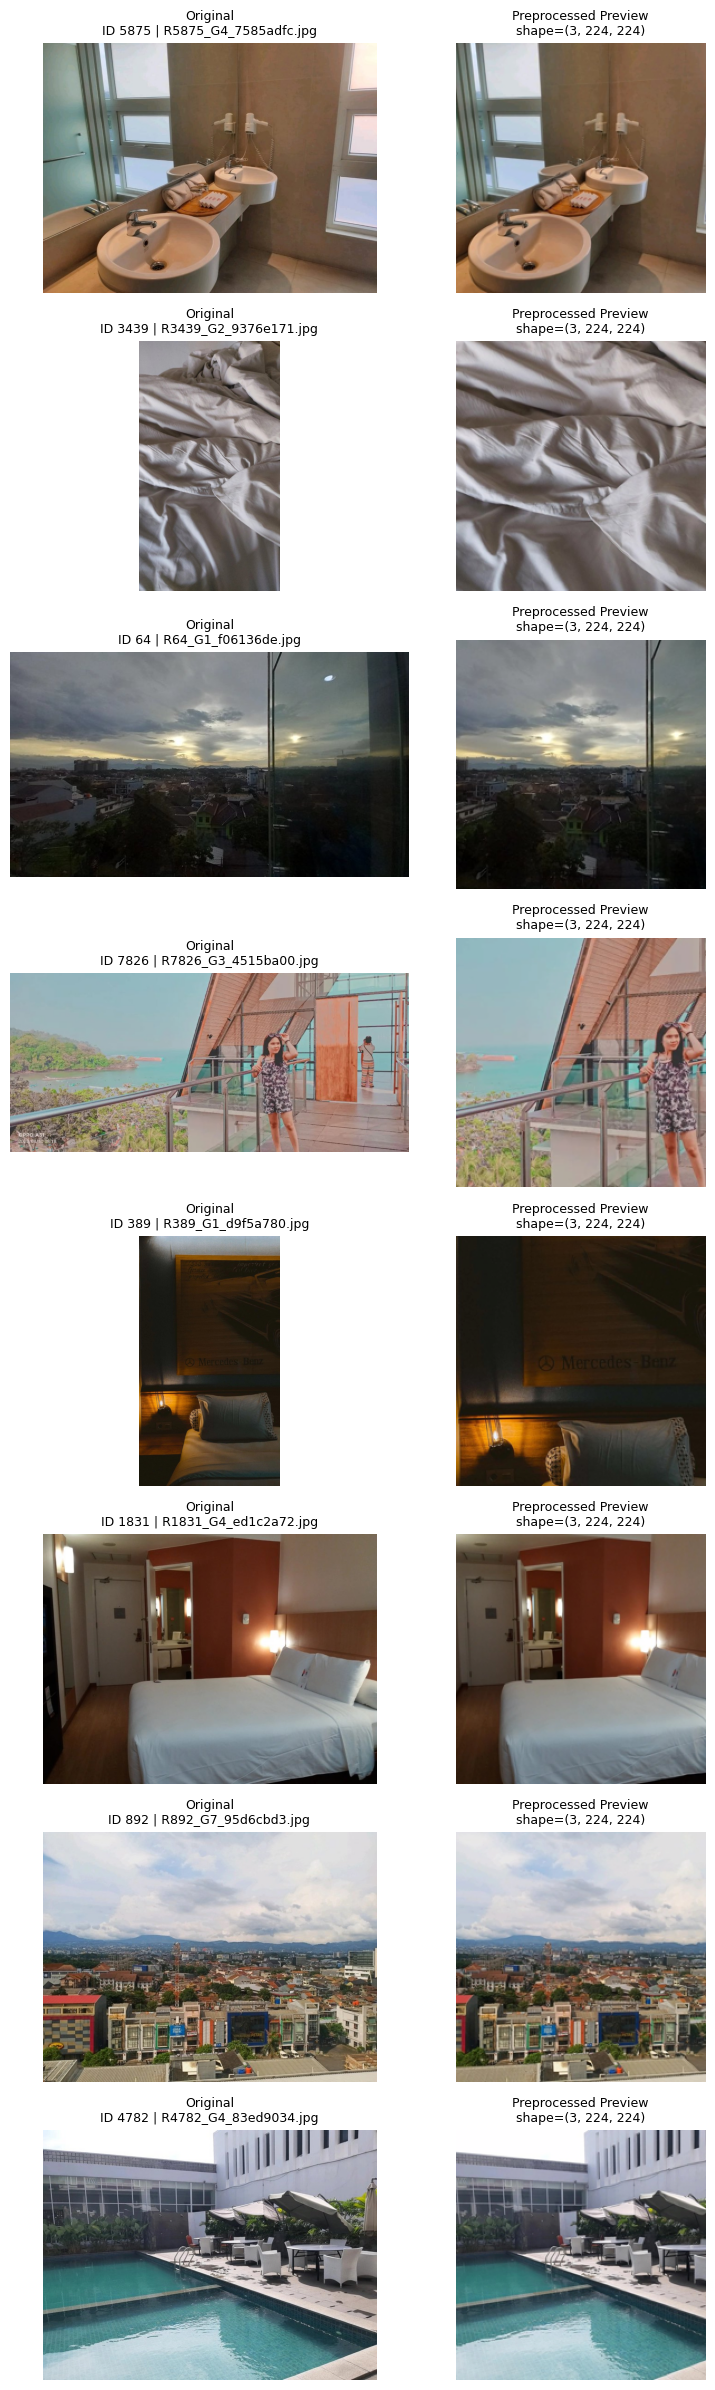

In [12]:
import matplotlib.pyplot as plt

def denormalize_clip_tensor(pixel_values):
    """
    Convert preprocessed CLIP-style tensor/array back to displayable image.
    Input shape: (3, H, W)
    Output shape: (H, W, 3)
    """
    mean = np.asarray([0.48145466, 0.4578275, 0.40821073], dtype=np.float32)
    std = np.asarray([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)

    arr = np.asarray(pixel_values).astype(np.float32)

    if arr.shape[0] == 3:
        arr = np.transpose(arr, (1, 2, 0))

    arr = (arr * std) + mean
    arr = np.clip(arr, 0, 1)
    return arr


preview_n = min(8, len(sample_df))
fig, axes = plt.subplots(preview_n, 2, figsize=(8, preview_n * 3))

if preview_n == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(sample_df.head(preview_n).iterrows()):
    original_img = load_rgb_image(row["Image_Path"])
    processed_img = denormalize_clip_tensor(sample_pixel_values[row_idx])

    axes[row_idx, 0].imshow(original_img)
    axes[row_idx, 0].set_title(
        f"Original\nID {row['ID_Review']} | {row['Image_FileName']}",
        fontsize=9
    )
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(processed_img)
    axes[row_idx, 1].set_title(
        f"Preprocessed Preview\nshape={sample_pixel_values[row_idx].shape}",
        fontsize=9
    )
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

### 13. Pemetaan Identitas Mask Berdasarkan Varian Dataset Multimodal


In [13]:
variant_masks = {
    "all_valid": np.ones(len(image_manifest_prepared), dtype=bool),
}

for variant_name, variant_df in image_datasets.items():
    key = variant_df["ID_Review"].astype(str) + "__" + variant_df["Image_FileName"].astype(str)
    variant_keys = set(key)
    prepared_key = image_manifest_prepared["ID_Review"].astype(str) + "__" + image_manifest_prepared["Image_FileName"].astype(str)
    variant_masks[variant_name] = prepared_key.isin(variant_keys).to_numpy()


def save_npz_index(variant_name, mask):
    path = OUTPUT_DIR / f"image_dataset_index_{variant_name}.npz"
    np.savez_compressed(
        path,
        labels=label_image_matrix[mask],
        review_ids=image_manifest_prepared.loc[mask, "ID_Review"].astype(str).to_numpy(),
        image_filenames=image_manifest_prepared.loc[mask, "Image_FileName"].astype(str).to_numpy(),
        image_paths=image_manifest_prepared.loc[mask, "Image_Path"].astype(str).to_numpy(),
        split_ids=image_manifest_prepared.loc[mask, "split_id"].fillna(-1).to_numpy(dtype=np.int64),
        dataset_role_ids=image_manifest_prepared.loc[mask, "dataset_role_id"].fillna(-1).to_numpy(dtype=np.int64),
        usable_image=image_manifest_prepared.loc[mask, "is_usable_image"].astype(bool).to_numpy(),
    )
    return path


saved_npz = []
for variant_name, mask in variant_masks.items():
    saved_npz.append(save_npz_index(variant_name, mask))

print("Saved image index NPZ files:")
for path in saved_npz:
    print("-", path.name)

Saved image index NPZ files:
- image_dataset_index_all_valid.npz
- image_dataset_index_primary_training.npz
- image_dataset_index_relation_aware.npz
- image_dataset_index_contradiction_ablation.npz


### 14. Ekspor Dataframe Image Manifest ke Format CSV


In [14]:
def save_csv(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path


image_output_columns = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    "Gambar_Ke", "Image_FileName", "Image_Path", "image_path_found", "file_exists",
    "valid_image", "is_usable_image", "format", "mode", "width", "height",
    "file_size_bytes", "aspect_ratio", "min_side", "max_side",
    "is_tiny_image", "is_extreme_aspect_ratio", "split", "split_id",
    "dataset_role", "dataset_role_id", "relation_category", "relation_strength",
    "policy_bucket", "recommended_fusion_strategy",
]
for aspect in ASPECTS:
    image_output_columns.extend([f"label_image_{aspect}", f"label_image_id_{aspect}"])

image_output_columns = [col for col in image_output_columns if col in image_manifest_prepared.columns]

saved_csv = []
saved_csv.append(save_csv(image_manifest_prepared[image_output_columns], "image_preprocessed_manifest_all_valid.csv"))
saved_csv.append(save_csv(image_manifest_prepared.loc[variant_masks["primary_training"], image_output_columns], "image_preprocessed_manifest_primary_training.csv"))
saved_csv.append(save_csv(image_manifest_prepared.loc[variant_masks["relation_aware"], image_output_columns], "image_preprocessed_manifest_relation_aware.csv"))
saved_csv.append(save_csv(image_manifest_prepared.loc[variant_masks["contradiction_ablation"], image_output_columns], "image_preprocessed_manifest_contradiction_ablation.csv"))
saved_csv.append(save_csv(image_file_audit, "image_file_audit_all_valid.csv"))
saved_csv.append(save_csv(image_manifest_prepared.loc[~image_manifest_prepared["is_usable_image"], image_output_columns], "invalid_or_unusable_images.csv"))
saved_csv.append(save_csv(image_quality_summary, "image_quality_summary.csv"))
saved_csv.append(save_csv(format_distribution, "image_format_distribution.csv"))
saved_csv.append(save_csv(mode_distribution, "image_mode_distribution.csv"))
saved_csv.append(save_csv(size_by_split_role, "image_size_by_split_role.csv"))
saved_csv.append(save_csv(review_image_group, "review_level_image_group_mapping.csv"))
saved_csv.append(save_csv(sample_batch_summary, "sample_image_batch_summary.csv"))
saved_csv.append(save_csv(duplicate_filename_scan, "duplicate_filename_scan.csv"))

print("Saved CSV files:")
for path in saved_csv:
    print("-", path.name)

Saved CSV files:
- image_preprocessed_manifest_all_valid.csv
- image_preprocessed_manifest_primary_training.csv
- image_preprocessed_manifest_relation_aware.csv
- image_preprocessed_manifest_contradiction_ablation.csv
- image_file_audit_all_valid.csv
- invalid_or_unusable_images.csv
- image_quality_summary.csv
- image_format_distribution.csv
- image_mode_distribution.csv
- image_size_by_split_role.csv
- review_level_image_group_mapping.csv
- sample_image_batch_summary.csv
- duplicate_filename_scan.csv


### 15. Ekspor Metadata Kebijakan Preprocessing Gambar (Format JSON)


In [15]:
preprocessing_policy = {
    "image_model_name": IMAGE_MODEL_NAME,
    "processor_source": processor_source if image_processor is not None else "manual_fallback",
    "processor_loaded": image_processor is not None,
    "target_image_size": TARGET_IMAGE_SIZE,
    "rgb_conversion": True,
    "exif_transpose": True,
    "store_full_pixel_cache": False,
    "reason_no_full_pixel_cache": "Menyimpan tensor seluruh 17k image akan membesarkan output Kaggle. Training notebook akan memuat gambar dari manifest.",
    "image_level_training": True,
    "review_level_multi_image_mapping": True,
    "label_to_id": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "split_to_id": split_to_id,
    "role_to_id": role_to_id,
}

if image_processor is not None:
    try:
        preprocessing_policy["image_processor_config"] = image_processor.to_dict()
    except Exception:
        preprocessing_policy["image_processor_config"] = str(image_processor)

summary = {
    "total_image_rows": int(len(image_manifest_prepared)),
    "path_found": int(image_manifest_prepared["image_path_found"].sum()),
    "valid_images": int(image_manifest_prepared["valid_image"].sum()),
    "usable_images": int(image_manifest_prepared["is_usable_image"].sum()),
    "invalid_or_unusable_images": int((~image_manifest_prepared["is_usable_image"]).sum()),
    "unique_reviews": int(image_manifest_prepared["ID_Review"].nunique()),
    "split_counts": image_manifest_prepared["split"].value_counts().to_dict(),
    "dataset_role_counts": image_manifest_prepared["dataset_role"].value_counts().to_dict(),
    "format_distribution": format_distribution.to_dict(orient="records"),
    "mode_distribution": mode_distribution.to_dict(orient="records"),
    "quality_summary": image_quality_summary.to_dict(orient="records"),
    "sample_batch_summary": sample_batch_summary.to_dict(orient="records"),
    "split_leakage_by_review": int(split_leakage_by_review),
    "invalid_label_ids": int(invalid_label_ids),
    "recommended_next_notebook": "07_text_only_baseline_indobert.ipynb after Notebook 06/08 preprocessing is available; roadmap next is Notebook 07 only after Notebook 06 is analyzed.",
}

with open(OUTPUT_DIR / "image_preprocessing_policy.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_policy, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / "image_preprocessing_feature_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

methodology_notes = f"""# Methodology Notes - Notebook 06 Image Preprocessing Feature Dataset

## Tujuan

Notebook 06 menyiapkan data gambar dari folder `image_cache` untuk baseline image-only dan model multimodal. Tahap ini belum melakukan training.

## Dasar Metodologi

1. ViT memproses gambar sebagai patch visual berukuran tetap, sehingga ukuran input perlu konsisten.
2. CLIP menyediakan representasi image-text yang kuat untuk transfer learning dan cocok sebagai encoder visual baseline.
3. Pretrained image encoder memiliki preprocessing spesifik. Karena itu, notebook memakai `AutoImageProcessor` bila tersedia.
4. Dataset hotel ini memiliki multi-image per review, sehingga notebook menyimpan image-level manifest dan review-level grouping.

## Keputusan Preprocessing

- Model image processor: {IMAGE_MODEL_NAME}
- Processor source: {processor_source if image_processor is not None else "manual_fallback"}
- Target image size fallback: {TARGET_IMAGE_SIZE}
- Full tensor cache: tidak, karena terlalu besar untuk output Kaggle.
- Training berikutnya memuat gambar dari `Image_Path` pada manifest.

## Ringkasan Kualitas

- Total image rows: {len(image_manifest_prepared)}
- Path found: {int(image_manifest_prepared["image_path_found"].sum())}
- Valid images: {int(image_manifest_prepared["valid_image"].sum())}
- Usable images: {int(image_manifest_prepared["is_usable_image"].sum())}
- Invalid/unusable images: {int((~image_manifest_prepared["is_usable_image"]).sum())}
- Reviews with split leakage: {int(split_leakage_by_review)}

"""

with open(OUTPUT_DIR / "methodology_notes_notebook_06.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

print(json.dumps(summary, ensure_ascii=False, indent=2)[:6000])

{
  "total_image_rows": 17371,
  "path_found": 17371,
  "valid_images": 17371,
  "usable_images": 17371,
  "invalid_or_unusable_images": 0,
  "unique_reviews": 8030,
  "split_counts": {
    "train": 12198,
    "val": 2628,
    "test": 2545
  },
  "dataset_role_counts": {
    "core_clean_training": 10429,
    "relation_aware_training": 3529,
    "contradiction_ablation": 3395,
    "all_none_control": 18
  },
  "format_distribution": [
    {
      "format": "JPEG",
      "count": 17371,
      "percentage": 100.0
    }
  ],
  "mode_distribution": [
    {
      "mode": "RGB",
      "count": 17371,
      "percentage": 100.0
    }
  ],
  "quality_summary": [
    {
      "total_rows": 17371,
      "path_found": 17371,
      "valid_image": 17371,
      "usable_image": 17371,
      "missing_path": 0,
      "invalid_image": 0,
      "tiny_image": 1,
      "extreme_aspect_ratio": 5,
      "median_width": 720.0,
      "median_height": 960.0,
      "p05_min_side": 405.0,
      "p95_max_side": 1024.

### 16. Verifikasi Akhir Integritas File Gambar (Critical Checks)


In [16]:
checks = []

checks.append({
    "check": "all_manifest_rows_have_path",
    "value": int(image_manifest_prepared["image_path_found"].sum()),
    "expected": int(len(image_manifest_prepared)),
})
checks.append({
    "check": "all_manifest_rows_are_valid_images",
    "value": int(image_manifest_prepared["valid_image"].sum()),
    "expected": int(len(image_manifest_prepared)),
})
checks.append({
    "check": "all_manifest_rows_are_usable_images",
    "value": int(image_manifest_prepared["is_usable_image"].sum()),
    "expected": int(len(image_manifest_prepared)),
})
checks.append({
    "check": "no_review_split_leakage",
    "value": int(split_leakage_by_review),
    "expected": 0,
})
checks.append({
    "check": "invalid_label_ids",
    "value": int(invalid_label_ids),
    "expected": 0,
})
checks.append({
    "check": "label_matrix_rows_match_manifest",
    "value": int(label_image_matrix.shape[0]),
    "expected": int(len(image_manifest_prepared)),
})
checks.append({
    "check": "sample_batch_file_exists",
    "value": int((OUTPUT_DIR / "sample_image_batch_preprocessed.npz").exists()),
    "expected": 1,
})
checks.append({
    "check": "preprocessing_policy_exists",
    "value": int((OUTPUT_DIR / "image_preprocessing_policy.json").exists()),
    "expected": 1,
})

checks_df = pd.DataFrame(checks)
checks_df["status"] = checks_df.apply(lambda row: "OK" if row["value"] == row["expected"] else "NEEDS_REVIEW", axis=1)
checks_df.to_csv(OUTPUT_DIR / "notebook_06_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 06 selesai dengan catatan. Cek baris NEEDS_REVIEW sebelum Notebook 08/09/10.")
else:
    print("Notebook 06 selesai. Dataset gambar siap untuk Notebook 08 image-only baseline dan notebook multimodal berikutnya.")

,check,value,expected,status
0,all_manifest_rows_have_path,17371,17371,OK
1,all_manifest_rows_are_valid_images,17371,17371,OK
2,all_manifest_rows_are_usable_images,17371,17371,OK
3,no_review_split_leakage,0,0,OK
4,invalid_label_ids,0,0,OK
5,label_matrix_rows_match_manifest,17371,17371,OK
6,sample_batch_file_exists,1,1,OK
7,preprocessing_policy_exists,1,1,OK


Notebook 06 selesai. Dataset gambar siap untuk Notebook 08 image-only baseline dan notebook multimodal berikutnya.


### 17. Pembuatan Arsip ZIP untuk Output Preprocessing Gambar


In [17]:
zip_base = OUTPUT_DIR.parent / "mabsa_image_preprocessing_feature_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_image_preprocessing_feature_outputs.zip

Files in output directory:
- duplicate_filename_scan.csv
- image_dataset_index_all_valid.npz
- image_dataset_index_contradiction_ablation.npz
- image_dataset_index_primary_training.npz
- image_dataset_index_relation_aware.npz
- image_file_audit_all_valid.csv
- image_format_distribution.csv
- image_mode_distribution.csv
- image_preprocessed_manifest_all_valid.csv
- image_preprocessed_manifest_contradiction_ablation.csv
- image_preprocessed_manifest_primary_training.csv
- image_preprocessed_manifest_relation_aware.csv
- image_preprocessing_feature_summary.json
- image_preprocessing_policy.json
- image_quality_summary.csv
- image_size_by_split_role.csv
- invalid_or_unusable_images.csv
- methodology_notes_notebook_06.md
- notebook_06_checks.csv
- review_level_image_group_mapping.csv
- sample_image_batch_preprocessed.npz
- sample_image_batch_summary.csv
